Author: Henry CH Yeung

### Comparing Classification Result

In [1]:
import os
import rasterio
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gps
from rasterstats import zonal_stats

In [2]:
os.getcwd()

'/Users/apm5rt/Library/CloudStorage/OneDrive-UniversityofVirginia/code_deepLearning/dryland_multiU-Net_NorthCarolinaNAIP/notebooks/scripts'

In [3]:
# Import dataset
det = rasterio.open('../../predictions/det_merged.tif').read(1)
ndvi_data = rasterio.open('../../rawImage/ndvi_merged.tif')
ndvi = ndvi_data.read(1)
rgi_data = rasterio.open('../../rawImage/rgi_merged.tif')
rgi = rgi_data.read(1)
ann = gps.read_file('../../training/trainingPolygon.shp')

RasterioIOError: ../../predictions/det_merged.tif: No such file or directory

In [6]:
# 1. Calculate zonal statistics of annotation
ann['label'].fillna(value=2, inplace=True)
ann['meanNDVI'] = pd.DataFrame(zonal_stats(ann, ndvi, affine=ndvi_data.transform, stats=['mean']))
ann['meanRGI'] = pd.DataFrame(zonal_stats(ann, rgi, affine=rgi_data.transform, stats=['mean']))
ndviLive_ann = ann['meanNDVI'].loc[ann.label==2].values
ndviDead_ann = ann['meanNDVI'].loc[ann.label==1].values
rgiLive_ann = ann['meanRGI'].loc[ann.label==2].values
rgiDead_ann = ann['meanRGI'].loc[ann.label==1].values

/Users/apm5rt/opt/anaconda3/envs/deep/lib/python3.7/site-packages/rasterstats/io.py:301: UserWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn("Setting nodata to -999; specify nodata explicitly")


In [7]:
# 2. Processing raster data
ndviLive = np.where((det == 2), ndvi, np.nan).flatten()
ndviDead = np.where((det == 1), ndvi, np.nan).flatten()
rgiLive = np.where((det == 2), rgi, np.nan).flatten()
rgiDead = np.where((det == 1), rgi, np.nan).flatten()

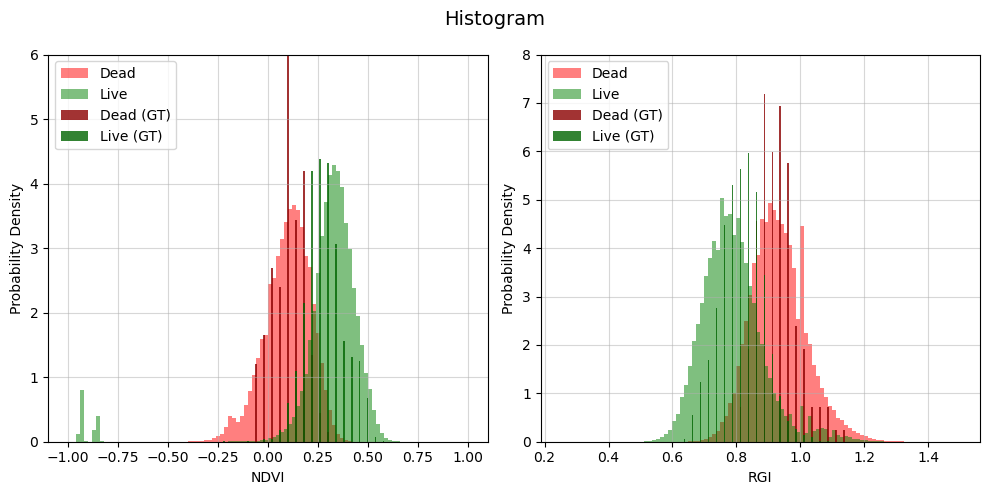

In [11]:
bins = 100
fig, ax = plt.subplots(1,2, figsize=(10,5))

# NDVI
ax[0].hist(ndviDead, bins=bins, range=[-1,1], alpha=0.5, density=True, histtype='stepfilled', label='Dead', color='red')
ax[0].hist(ndviLive, bins=bins, range=[-1,1], alpha=0.5, density=True, histtype='stepfilled', label='Live', color='green')
ax[0].hist(ndviDead_ann, bins=round(bins/2), range=[-1,1], rwidth=0.2, alpha=0.8, density=True, histtype='bar', label='Dead (GT)', color='darkred')
ax[0].hist(ndviLive_ann, bins=round(bins/2), range=[-1,1], rwidth=0.2, alpha=0.8, density=True, histtype='bar', label='Live (GT)', color='darkgreen')
ax[0].set_xlabel('NDVI')
ax[0].legend(loc='upper left')
ax[0].grid(alpha=0.5)
ax[0].set_ylabel('Probability Density')
ax[0].set_ylim(0, 6)

# RGI
ax[1].hist(rgiDead, bins=bins, range=[0.25,1.5], alpha=0.5, density=True, histtype='stepfilled', label='Dead', color='red')
ax[1].hist(rgiLive, bins=bins, range=[0.25,1.5], alpha=0.5, density=True, histtype='stepfilled', label='Live', color='green')
ax[1].hist(rgiDead_ann, bins=round(bins/2), range=[0.25,1.5], rwidth=0.2, alpha=0.8, density=True, histtype='bar', label='Dead (GT)', color='darkred')
ax[1].hist(rgiLive_ann, bins=round(bins/2), range=[0.25,1.5], rwidth=0.2, alpha=0.8, density=True, histtype='bar', label='Live (GT)', color='darkgreen')
ax[1].set_xlabel('RGI')
ax[1].legend(loc='upper left')
ax[1].grid(alpha=0.5)
ax[1].set_ylabel('Probability Density')
ax[1].set_ylim(0, 8)
fig.suptitle('Histogram', fontsize=14)
fig.tight_layout()
plt.show()

### Plotting spectrum

In [18]:
det = rasterio.open('../../predictions/det_proj_m_3507517_sw_18_060_20200516.tif').read(1)
image_data = rasterio.open('../../source/proj_m_3507517_sw_18_060_20200516.tif')
image = image_data.read()

In [19]:
# Mask with class label
specLive = np.where((det == 2), image, np.nan)
specDead = np.where((det == 1), image, np.nan)

In [20]:
ann['meanR'] = pd.DataFrame(zonal_stats(ann, image[0,...], affine=image_data.transform, stats=['mean']))
ann['meanG'] = pd.DataFrame(zonal_stats(ann, image[1,...], affine=image_data.transform, stats=['mean']))
ann['meanB'] = pd.DataFrame(zonal_stats(ann, image[2,...], affine=image_data.transform, stats=['mean']))
ann['meanN'] = pd.DataFrame(zonal_stats(ann, image[3,...], affine=image_data.transform, stats=['mean']))

In [21]:
q25Live, q50Live, q75Live = np.nanpercentile(specLive, [25,50,75], axis=(1,2))
q25Dead, q50Dead, q75Dead = np.nanpercentile(specDead, [25,50,75], axis=(1,2))

q25Live_ann, q50Live_ann, q75Live_ann = np.nanpercentile(ann[['meanR', 'meanG', 'meanB', 'meanN']].loc[ann.label==2].values, [25,50,75], axis=0)
q25Dead_ann, q50Dead_ann, q75Dead_ann = np.nanpercentile(ann[['meanR', 'meanG', 'meanB', 'meanN']].loc[ann.label==1].values, [25,50,75], axis=0)

In [23]:
q50Live_ann

array([ 72.84615385,  93.49275362,  59.78947368, 150.09090909])

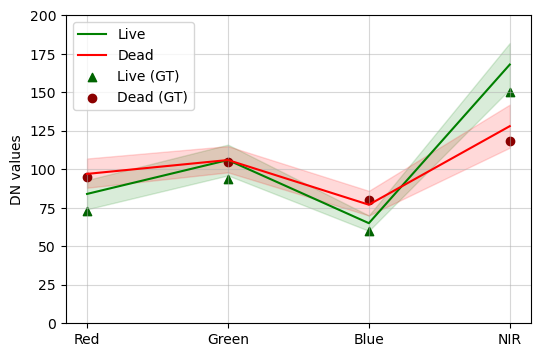

In [25]:
fig, ax = plt.subplots(figsize=(6,4))
x = np.arange(0,4)
ax.fill_between(x, q25Live, q75Live, color='green', alpha=0.15)
ax.fill_between(x, q25Dead, q75Dead, color='red', alpha=0.15)
ax.plot(x, q50Live, label='Live', color='green')
ax.plot(x, q50Dead, label='Dead', color='red')

ax.scatter(x, q50Live_ann, label='Live (GT)', color='darkgreen', marker='^')
# ax.errorbar(x, [q25Live_ann, q75Live_ann], color='darkgreen')
ax.scatter(x, q50Dead_ann, label='Dead (GT)', color='darkred', marker='o')

ax.legend(loc='upper left')
ax.set_ylim(0,200)
ax.set_xticks(x, ['Red', 'Green', 'Blue', 'NIR'])
ax.set_ylabel('DN values')
ax.grid(alpha=0.5)